# ERA5 vs BARRA-RE2 selected realization comparison

This notebook makes **one figure with 3 side-by-side panels**:

1. **ERA5** climatological annual wind-drought days.
2. **BARRA-RE2 selected realization** `008_0` climatological annual wind-drought days.
3. **Difference** = `BARRA-RE2 008_0 - ERA5`.

Notes:
- The user already identified `008_0` as the BARRA realization with the highest difference from ERA5, so this notebook does **not** re-rank realizations.
- Because BARRA-RE2 and ERA5 do not have the same grid, the BARRA field is interpolated to the **ERA5 grid** before calculating the difference.
- The figure uses a **single-row, 3-panel layout**.


In [1]:
import os
from glob import glob

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from tqdm.auto import tqdm


In [2]:
# =====================
# Settings
# =====================
BARRA_INPUT_DIR = "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly"
ERA5_INPUT_DIR = "/g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5"

OUTPUT_DIR = "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/single_realization_vs_era5"
os.makedirs(OUTPUT_DIR, exist_ok=True)

START_YEAR = 1990
END_YEAR = 2025

lon_min, lon_max = 110, 160
lat_min, lat_max = -45, -10

threshold_percentile = 20
persistence_days = 3

BARRA_PATTERN = "wind_drought_P20_3day_*.nc"
ERA5_PATTERN = "wind_drought_P20_3day_*.nc"

TARGET_REALIZATION_LABEL = "008_0"

# Same general style as your earlier frequency plots
levels = np.arange(3, 42, 3)

OUT_FIG = os.path.join(
    OUTPUT_DIR,
    f"ERA5_vs_BARRA_RE2_{TARGET_REALIZATION_LABEL}_and_difference_1990_2025.png"
)

OUT_NC = os.path.join(
    OUTPUT_DIR,
    f"ERA5_vs_BARRA_RE2_{TARGET_REALIZATION_LABEL}_and_difference_1990_2025.nc"
)

print("Output directory:", OUTPUT_DIR)
print("Target realization:", TARGET_REALIZATION_LABEL)


Output directory: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/single_realization_vs_era5
Target realization: 008_0


In [3]:
# =====================
# Helper functions
# =====================
def year_from_filename(fp):
    return int(os.path.basename(fp).split("_")[-1].split(".")[0])


def get_year_files(input_dir, pattern, start_year, end_year):
    files = sorted(glob(os.path.join(input_dir, pattern)))
    out = []
    for fp in files:
        yr = year_from_filename(fp)
        if start_year <= yr <= end_year:
            out.append(fp)
    if len(out) == 0:
        raise FileNotFoundError(f"No files found in {input_dir} for {start_year}-{end_year}")
    return out


def get_var_name(ds):
    if "wind_drought" in ds.data_vars:
        return "wind_drought"
    return list(ds.data_vars)[0]


def get_lon_lat_names(obj):
    names = list(obj.coords) + list(obj.dims)

    if "lon" in names:
        lon_name = "lon"
    elif "longitude" in names:
        lon_name = "longitude"
    else:
        raise KeyError("Could not find lon or longitude coordinate")

    if "lat" in names:
        lat_name = "lat"
    elif "latitude" in names:
        lat_name = "latitude"
    else:
        raise KeyError("Could not find lat or latitude coordinate")

    return lon_name, lat_name


def crop_australia(da):
    lon_name, lat_name = get_lon_lat_names(da)
    lon = da[lon_name]
    lat = da[lat_name]

    return da.where(
        (lon >= lon_min) & (lon <= lon_max) &
        (lat >= lat_min) & (lat <= lat_max),
        drop=True
    )


def standardise_lon_lat(da):
    rename = {}

    if "longitude" in da.dims:
        rename["longitude"] = "lon"
    if "latitude" in da.dims:
        rename["latitude"] = "lat"
    if "longitude" in da.coords:
        rename["longitude"] = "lon"
    if "latitude" in da.coords:
        rename["latitude"] = "lat"

    if rename:
        da = da.rename(rename)

    return da


def standardise_for_plot(da):
    da = standardise_lon_lat(da)

    rename = {}
    if "lon" in da.dims:
        rename["lon"] = "longitude"
    if "lat" in da.dims:
        rename["lat"] = "latitude"
    if "lon" in da.coords:
        rename["lon"] = "longitude"
    if "lat" in da.coords:
        rename["lat"] = "latitude"

    if rename:
        da = da.rename(rename)

    for d in list(da.dims):
        if d not in ["latitude", "longitude"]:
            if da.sizes[d] == 1:
                da = da.isel({d: 0}, drop=True)
            else:
                raise ValueError(f"Unexpected non-spatial dimension for plotting: {d}")

    da = da.transpose("latitude", "longitude")
    return da


def compute_similarity_metrics(candidate, reference):
    diff = candidate - reference
    mad = float(np.abs(diff).mean(skipna=True).values)
    bias = float(diff.mean(skipna=True).values)
    rmse = float(np.sqrt((diff ** 2).mean(skipna=True).values))
    return diff, mad, bias, rmse


def select_target_realization(da, label):
    if "realization" not in da.dims and "realization" not in da.coords:
        raise KeyError("BARRA data does not contain a realization dimension")

    real_vals = da["realization"].values
    real_str = [str(v) for v in real_vals]

    if label in real_str:
        idx = real_str.index(label)
        return da.isel(realization=idx), idx, real_vals[idx]

    # fallback in case labels are stored differently
    cleaned = [s.replace("'", "").strip() for s in real_str]
    if label in cleaned:
        idx = cleaned.index(label)
        return da.isel(realization=idx), idx, real_vals[idx]

    raise KeyError(f"Target realization {label} not found. Available values: {real_str}")


In [4]:
# =====================
# Find files
# =====================
barra_files = get_year_files(BARRA_INPUT_DIR, BARRA_PATTERN, START_YEAR, END_YEAR)
era5_files = get_year_files(ERA5_INPUT_DIR, ERA5_PATTERN, START_YEAR, END_YEAR)

print("BARRA files:", len(barra_files))
print("BARRA first:", barra_files[0])
print("BARRA last :", barra_files[-1])

print("ERA5 files:", len(era5_files))
print("ERA5 first:", era5_files[0])
print("ERA5 last :", era5_files[-1])


BARRA files: 36
BARRA first: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1990.nc
BARRA last : /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_2025.nc
ERA5 files: 36
ERA5 first: /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5/wind_drought_P20_3day_1990.nc
ERA5 last : /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5/wind_drought_P20_3day_2025.nc


In [5]:
# =====================
# Inspect one BARRA and one ERA5 file
# =====================
with xr.open_dataset(barra_files[0], engine="netcdf4", decode_times=True) as ds0:
    barra_var = get_var_name(ds0)
    print("BARRA dataset:")
    print(ds0)
    print("BARRA variable:", barra_var)
    print("BARRA dims:", ds0[barra_var].dims)
    if "realization" in ds0[barra_var].coords or "realization" in ds0[barra_var].dims:
        print("BARRA realizations:", ds0[barra_var]["realization"].values)

with xr.open_dataset(era5_files[0], engine="netcdf4", decode_times=True) as ds0:
    era5_var = get_var_name(ds0)
    print("ERA5 dataset:")
    print(ds0)
    print("ERA5 variable:", era5_var)
    print("ERA5 dims:", ds0[era5_var].dims)


BARRA dataset:
<xarray.Dataset> Size: 1GB
Dimensions:       (time: 365, realization: 22, lon: 227, lat: 159)
Coordinates:
  * time          (time) datetime64[ns] 3kB 1990-01-01T12:00:00 ... 1990-12-3...
  * realization   (realization) <U5 440B '000_0' '000_1' ... 'ctl_0' 'ctl_1'
  * lon           (lon) float64 2kB 110.2 110.4 110.7 ... 159.5 159.7 159.9
  * lat           (lat) float64 1kB -44.83 -44.61 -44.39 ... -10.29 -10.07
Data variables:
    wind_drought  (time, realization, lon, lat) float32 1GB ...
Attributes:
    title:    BARRA-RE2 wind drought mask for 1990
    history:  Created from monthly wind100 files using fixed 1991-2020 P20 th...
    region:   Australia
    lon_min:  110
    lon_max:  160
    lat_min:  -45
    lat_max:  -10
BARRA variable: wind_drought
BARRA dims: ('time', 'realization', 'lon', 'lat')
BARRA realizations: ['000_0' '000_1' '001_0' '001_1' '002_0' '002_1' '003_0' '003_1' '004_0'
 '004_1' '005_0' '005_1' '006_0' '006_1' '007_0' '007_1' '008_0' '008_1'
 '00

In [6]:
# =====================
# Compute ERA5 climatological annual drought days
# =====================
era5_annual_list = []
era5_years = []

for fp in tqdm(era5_files, desc="ERA5 yearly files"):
    year = year_from_filename(fp)

    ds = xr.open_dataset(fp, engine="netcdf4", decode_times=True)
    wd = ds[era5_var]
    wd = crop_australia(wd)

    days = wd.sum(dim="time", skipna=True).astype("float32")
    days.name = "annual_wind_drought_days"

    era5_annual_list.append(days.load())
    era5_years.append(year)
    ds.close()

era5_annual = xr.concat(era5_annual_list, dim="year")
era5_annual = era5_annual.assign_coords(year=era5_years)
era5_annual.name = "annual_wind_drought_days"

era5_clim = era5_annual.mean(dim="year", skipna=True).astype("float32")
era5_clim.name = "climatological_wind_drought_days"
era5_clim.attrs["long_name"] = "ERA5 climatological annual wind drought days"
era5_clim.attrs["units"] = "days/year"
era5_clim.attrs["period"] = f"{START_YEAR}-{END_YEAR}"

print(era5_annual)
print(era5_clim)


ERA5 yearly files:   0%|          | 0/36 [00:00<?, ?it/s]

<xarray.DataArray 'annual_wind_drought_days' (year: 36, latitude: 141,
                                              longitude: 201)> Size: 4MB
array([[[48., 50., 50., ..., 30., 37., 47.],
        [47., 44., 39., ..., 37., 38., 47.],
        [42., 44., 43., ..., 37., 38., 48.],
        ...,
        [19., 19., 19., ..., 22., 22., 22.],
        [16., 16., 19., ..., 19., 19., 19.],
        [13., 13., 13., ..., 16., 16., 19.]],

       [[73., 72., 71., ..., 27., 36., 33.],
        [69., 64., 72., ..., 40., 44., 46.],
        [67., 68., 68., ..., 42., 44., 43.],
        ...,
        [45., 44., 41., ..., 13., 12., 16.],
        [41., 41., 41., ..., 20., 22., 13.],
        [44., 41., 41., ..., 19., 19., 19.]],

       [[85., 82., 80., ..., 29., 34., 28.],
        [81., 78., 79., ..., 35., 37., 39.],
        [83., 80., 78., ..., 35., 33., 38.],
        ...,
...
        [33., 37., 35., ..., 10., 10., 11.],
        [29., 32., 32., ..., 13., 13., 11.],
        [23., 19., 19., ..., 10., 13., 17.]]

In [7]:
# =====================
# Compute BARRA-RE2 climatological annual drought days for selected realization only
# =====================
barra_selected_annual = []
barra_years = []
selected_realization_coord = None
selected_realization_index = None

for fp in tqdm(barra_files, desc="BARRA yearly files"):
    year = year_from_filename(fp)

    ds = xr.open_dataset(fp, engine="netcdf4", decode_times=True)
    wd = ds[barra_var]
    wd = crop_australia(wd)

    wd_sel, idx, coord_value = select_target_realization(wd, TARGET_REALIZATION_LABEL)

    if selected_realization_coord is None:
        selected_realization_coord = coord_value
        selected_realization_index = idx

    days = wd_sel.sum(dim="time", skipna=True).astype("float32")
    days.name = "annual_wind_drought_days"

    barra_selected_annual.append(days.load())
    barra_years.append(year)
    ds.close()

barra_selected_annual = xr.concat(barra_selected_annual, dim="year")
barra_selected_annual = barra_selected_annual.assign_coords(year=barra_years)
barra_selected_annual.name = "annual_wind_drought_days_selected_realization"

barra_selected_clim = barra_selected_annual.mean(dim="year", skipna=True).astype("float32")
barra_selected_clim.name = "climatological_wind_drought_days_selected_realization"
barra_selected_clim.attrs["long_name"] = f"BARRA-RE2 climatological annual wind drought days for realization {TARGET_REALIZATION_LABEL}"
barra_selected_clim.attrs["units"] = "days/year"
barra_selected_clim.attrs["period"] = f"{START_YEAR}-{END_YEAR}"
barra_selected_clim.attrs["selected_realization"] = str(selected_realization_coord)
barra_selected_clim.attrs["selected_realization_index"] = int(selected_realization_index)

print("Selected realization coordinate value:", selected_realization_coord)
print("Selected realization index:", selected_realization_index)
print(barra_selected_annual)
print(barra_selected_clim)


BARRA yearly files:   0%|          | 0/36 [00:00<?, ?it/s]

Selected realization coordinate value: 008_0
Selected realization index: 16
<xarray.DataArray 'annual_wind_drought_days_selected_realization' (year: 36,
                                                                   lon: 227,
                                                                   lat: 159)> Size: 5MB
array([[[23., 23., 20., ..., 62., 58., 55.],
        [20., 23., 23., ..., 61., 57., 55.],
        [20., 23., 23., ..., 58., 59., 61.],
        ...,
        [15., 15., 13., ..., 24., 17., 16.],
        [15., 15., 13., ..., 31., 17., 20.],
        [15., 12., 12., ..., 28., 24., 23.]],

       [[38., 38., 38., ..., 51., 47., 45.],
        [38., 38., 38., ..., 50., 47., 43.],
        [35., 35., 35., ..., 46., 43., 41.],
        ...,
        [10., 13.,  9., ..., 34., 31., 34.],
        [16.,  9.,  6., ..., 31., 32., 29.],
        [15., 12.,  6., ..., 30., 34., 33.]],

       [[21., 24., 30., ..., 67., 66., 66.],
        [21., 22., 33., ..., 69., 66., 67.],
        [22., 33., 31.

In [8]:
# =====================
# Put BARRA on ERA5 grid and compute difference
# =====================
era5_std = standardise_lon_lat(era5_clim)
barra_std = standardise_lon_lat(barra_selected_clim)

# Interpolate BARRA onto ERA5 grid for fair comparison
barra_on_era5_grid = barra_std.interp(
    lon=era5_std["lon"],
    lat=era5_std["lat"],
    method="linear"
).astype("float32")

barra_on_era5_grid.name = "barra_selected_realization_on_era5_grid"
barra_on_era5_grid.attrs["long_name"] = f"BARRA-RE2 {TARGET_REALIZATION_LABEL} climatological annual wind drought days interpolated to ERA5 grid"
barra_on_era5_grid.attrs["interpolation_target"] = "ERA5 grid"

barra_plot, era5_plot = xr.align(barra_on_era5_grid, era5_std, join="inner")
barra_minus_era5, mad, bias, rmse = compute_similarity_metrics(barra_plot, era5_plot)
barra_minus_era5.name = "barra_minus_era5_difference"
barra_minus_era5.attrs["long_name"] = f"Difference in climatological annual wind drought days: BARRA-RE2 {TARGET_REALIZATION_LABEL} minus ERA5"
barra_minus_era5.attrs["units"] = "days/year"
barra_minus_era5.attrs["MAD"] = mad
barra_minus_era5.attrs["Bias"] = bias
barra_minus_era5.attrs["RMSE"] = rmse

print("MAD :", mad)
print("Bias:", bias)
print("RMSE:", rmse)
print("ERA5 shape:", era5_plot.shape)
print("BARRA on ERA5 grid shape:", barra_plot.shape)
print("Difference shape:", barra_minus_era5.shape)


MAD : 1.8072062730789185
Bias: -1.241396427154541
RMSE: 2.4705443382263184
ERA5 shape: (141, 201)
BARRA on ERA5 grid shape: (201, 141)
Difference shape: (201, 141)


In [9]:
# =====================
# Save output NetCDF
# =====================
out_ds = xr.Dataset({
    "era5_climatological_wind_drought_days": era5_std,
    "barra_selected_realization_native_grid": barra_std,
    "barra_selected_realization_on_era5_grid": barra_plot,
    "barra_minus_era5_difference": barra_minus_era5,
})

out_ds.attrs["title"] = "ERA5 vs BARRA-RE2 selected realization comparison"
out_ds.attrs["description"] = (
    f"Comparison of ERA5 and BARRA-RE2 realization {TARGET_REALIZATION_LABEL} for climatological annual wind drought days, "
    f"{START_YEAR}-{END_YEAR}. BARRA was interpolated to ERA5 grid before differencing."
)
out_ds.attrs["selected_realization"] = str(selected_realization_coord)
out_ds.attrs["selected_realization_index"] = int(selected_realization_index)
out_ds.attrs["threshold_percentile"] = threshold_percentile
out_ds.attrs["persistence_days"] = persistence_days
out_ds.attrs["MAD"] = mad
out_ds.attrs["Bias"] = bias
out_ds.attrs["RMSE"] = rmse

out_ds.to_netcdf(OUT_NC)
print("Saved:", OUT_NC)


Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/single_realization_vs_era5/ERA5_vs_BARRA_RE2_008_0_and_difference_1990_2025.nc


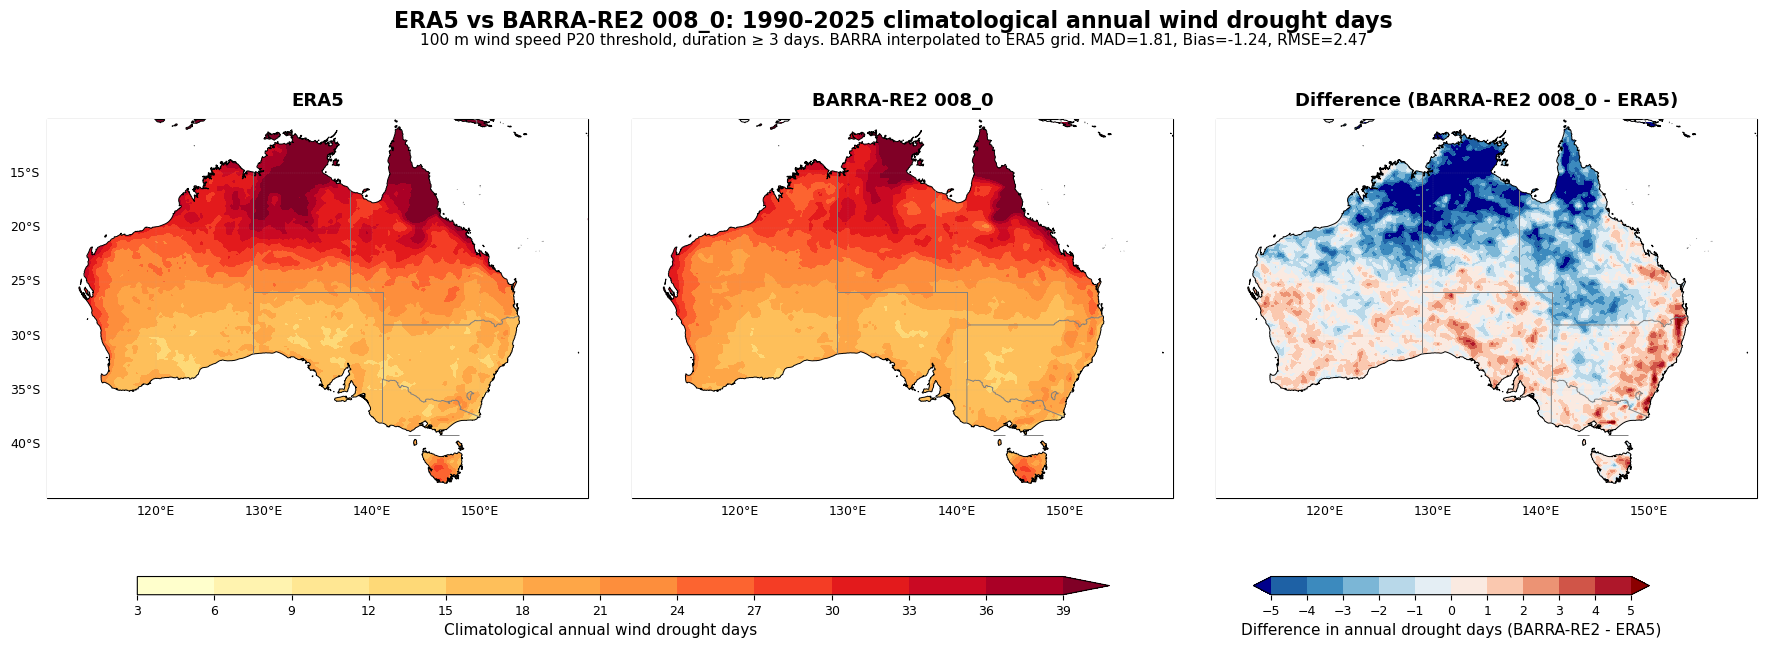

Saved figure: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/single_realization_vs_era5/ERA5_vs_BARRA_RE2_008_0_and_difference_1990_2025.png


In [14]:
# =====================
# Plot: 3 side-by-side panels in one row
# =====================
era5_plot_fig = standardise_for_plot(era5_std)
barra_plot_fig = standardise_for_plot(barra_plot)
diff_plot_fig = standardise_for_plot(barra_minus_era5)

# Main field colour scale
field_cmap = plt.cm.YlOrRd.copy()
field_cmap.set_under("white")
field_cmap.set_bad("white")
field_norm = mcolors.BoundaryNorm(levels, field_cmap.N, extend="max")

# Difference colour scale, symmetric around zero

'''
max_abs = float(np.nanmax(np.abs(diff_plot_fig.values)))
diff_vmax = max(6.0, float(np.ceil(max_abs / 3.0) * 3.0))
diff_levels = np.linspace(-diff_vmax, diff_vmax, 13)
diff_cmap = plt.cm.RdBu_r
'''
diff_levels = np.arange(-5, 6, 1)

diff_cmap = plt.cm.RdBu_r.copy()
diff_cmap.set_under("darkblue")
diff_cmap.set_over("darkred")
diff_cmap.set_bad("white")

diff_norm = mcolors.BoundaryNorm(
    diff_levels,
    diff_cmap.N,
    extend="both"
)

states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="10m",
    facecolor="none"
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6.5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=False
)

# Panel 1: ERA5
cf1 = axes[0].contourf(
    era5_plot_fig["longitude"],
    era5_plot_fig["latitude"],
    era5_plot_fig,
    levels=levels,
    cmap=field_cmap,
    norm=field_norm,
    extend="max",
    transform=ccrs.PlateCarree()
)

# Panel 2: BARRA selected realization
cf2 = axes[1].contourf(
    barra_plot_fig["longitude"],
    barra_plot_fig["latitude"],
    barra_plot_fig,
    levels=levels,
    cmap=field_cmap,
    norm=field_norm,
    extend="max",
    transform=ccrs.PlateCarree()
)

# Panel 3: Difference
cf3 = axes[2].contourf(
    diff_plot_fig["longitude"],
    diff_plot_fig["latitude"],
    diff_plot_fig,
    levels=diff_levels,
    cmap=diff_cmap,
    norm=diff_norm,
    extend="both",
    transform=ccrs.PlateCarree()
)


for i, ax in enumerate(axes):
    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=100)
    ax.coastlines(resolution="10m", linewidth=0.7, color="black", zorder=101)
    ax.add_feature(states, edgecolor="grey", linewidth=0.7, zorder=102)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linewidth=0.25, linestyle="--", alpha=0.35)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i == 0)
    gl.bottom_labels = True
    gl.xlabel_style = {"size": 9}
    gl.ylabel_style = {"size": 9}

axes[0].set_title("ERA5", fontsize=13, fontweight="bold", pad=10)
axes[1].set_title(f"BARRA-RE2 {TARGET_REALIZATION_LABEL}", fontsize=13, fontweight="bold", pad=10)
axes[2].set_title(f"Difference (BARRA-RE2 {TARGET_REALIZATION_LABEL} - ERA5)", fontsize=13, fontweight="bold", pad=10)

# Two colorbars: one shared for first two panels, one for difference
cbar1_ax = fig.add_axes([0.08, 0.08, 0.54, 0.028])
cbar1 = fig.colorbar(cf1, cax=cbar1_ax, orientation="horizontal")
cbar1.set_label("Climatological annual wind drought days", fontsize=11)
cbar1.set_ticks(levels)
cbar1.ax.tick_params(labelsize=9)

cbar2_ax = fig.add_axes([0.70, 0.08, 0.22, 0.028])

cbar2 = fig.colorbar(cf3, cax=cbar2_ax, orientation="horizontal")
cbar2.set_label("Difference in annual drought days (BARRA-RE2 - ERA5)", fontsize=11)
cbar2.set_ticks(diff_levels)
cbar2.ax.tick_params(labelsize=9)

fig.suptitle(
    f"ERA5 vs BARRA-RE2 {TARGET_REALIZATION_LABEL}: 1990-2025 climatological annual wind drought days",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.945,
    f"100 m wind speed P20 threshold, duration ≥ 3 days. BARRA interpolated to ERA5 grid. MAD={mad:.2f}, Bias={bias:+.2f}, RMSE={rmse:.2f}",
    ha="center",
    va="top",
    fontsize=11
)

plt.subplots_adjust(left=0.03, right=0.98, top=0.88, bottom=0.16, wspace=0.08)
plt.savefig(OUT_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", OUT_FIG)


In [ ]:

# =====================
# Check saved outputs
# =====================
print("Figure:", OUT_FIG)
print("NetCDF:", OUT_NC)

with xr.open_dataset(OUT_NC, engine="netcdf4") as check:
    print(check)
